# RK4 guiding-center area and symplecticity study

This experiment measures how the classical fourth-order Runge–Kutta method departs from symplecticity for physical guiding-center trajectories. Unlike the BM4 studies, RK4 evolves one physical state and has no duplicated copies, coupling, or projection.

For every complete RK4 step, the study differentiates the numerical map by centered finite differences. If $J_n$ is the Jacobian of one RK4 step and $DG_n$ is the accumulated Jacobian from the initial condition, the recorded defects are

$$\varepsilon_{\mathrm{local},n}=\frac{\|J_n^T\Omega J_n-\Omega\|_F}{\|\Omega\|_F},\qquad\varepsilon_{\mathrm{flow},n}=\frac{\|DG_n^T\Omega DG_n-\Omega\|_F}{\|\Omega\|_F}.$$

The transported polygon area and $|\det(DG_n)-1|$ provide complementary geometric diagnostics.

In [1]:
import numpy as np

from workflows import (
    RK4SymplecticityConfig,
    RandomPotentialConfig,
    centered_circle,
    display_animation,
    pi_area_steps,
    run_rk4_symplecticity_study,
)

## Reproducible configuration

The potential, boundary geometry, physical parameters, integration interval, three RK4 steps, observation interval, and differentiation scale are explicit below. They match the preceding BM4 area studies so the resulting magnitudes can be compared directly.

In [2]:
potential_config = RandomPotentialConfig(
    amplitude=0.7,
    max_wave_number=25,
    nx=64,
    ny=64,
    seed=27,
    interpolation_order=5,
)
potential = potential_config.build()

circle_radius = 0.5
circle_points = 16
rho = 0.3
circle = centered_circle(
    potential,
    radius=circle_radius,
    points=circle_points,
    rho=rho,
)

finite_difference_relative_step = float(np.cbrt(np.finfo(float).eps))
study_config = RK4SymplecticityConfig(
    steps=pi_area_steps(40, 80, 160),
    t_span=(0.0, 4 * np.pi),
    save_interval=np.pi / 8,
    chunk_size=16,
    progress=True,
    finite_difference_relative_step=finite_difference_relative_step,
)

print(potential_config)
print(
    f"Circle: {circle_points} points; t={study_config.t_span}; "
    f"{study_config.output_sample_count} saved states; "
    f"finite-difference relative step={finite_difference_relative_step:.8e}"
)

RandomPotentialConfig(amplitude=0.7, max_wave_number=25, nx=64, ny=64, seed=27, interpolation_order=5)
Circle: 16 points; t=(0.0, 12.566370614359172); 33 saved states; finite-difference relative step=6.05545445e-06


## RK4 integrations and persisted Jacobians

All complete RK4 steps contribute to the accumulated Jacobian. Scalar diagnostics and full local and accumulated Jacobians are persisted at the common observation times.

In [3]:
result = run_rk4_symplecticity_study(
    potential,
    circle,
    notebook_path=(
        "notebooks/experiments/symplecticity/"
        "gc_area_and_rk4_symplecticity.ipynb"
    ),
    config=study_config,
    metadata={
        **potential_config.metadata(),
        "circle_radius": circle_radius,
    },
)
result.print_summary()

RK4 [==============================] 100.0% (160/160, t=12.5664)
RK4 [==============================] 100.0% (320/320, t=12.5664)
RK4 [==============================] 100.0% (640/640, t=12.5664)


                  step  RK4 steps     max |area error|     max local defect      max flow defect      max |det-1|
     $\Delta t=\pi/40$        160       1.77844354e-02       6.22380128e-08       1.00794776e-06   4.66944671e-06
     $\Delta t=\pi/80$        320       1.77843764e-02       1.84922941e-09       6.16677634e-08   2.76841145e-07
    $\Delta t=\pi/160$        640       1.77843711e-02       6.97510521e-11       6.08729201e-09   2.14966533e-08

Empirical order of the maximum accumulated symplecticity defect:
  $\Delta t=\pi/40$ -> $\Delta t=\pi/80$: 4.030761
  $\Delta t=\pi/80$ -> $\Delta t=\pi/160$: 3.340644


## Time-dependent diagnostics

The local defect tests each RK4 step independently. The accumulated defect and determinant error test the complete discrete flow from the initial boundary, while the area panel shows the transported polygon geometry.

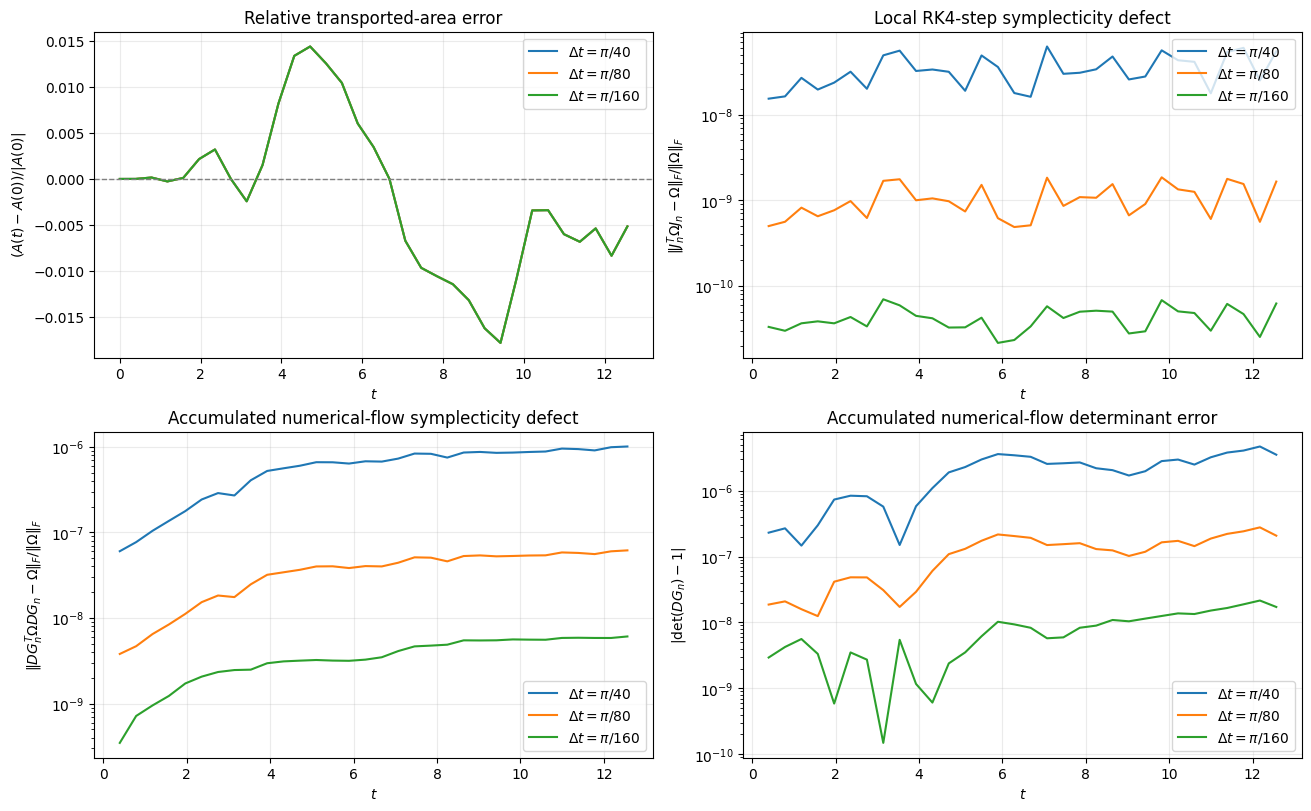

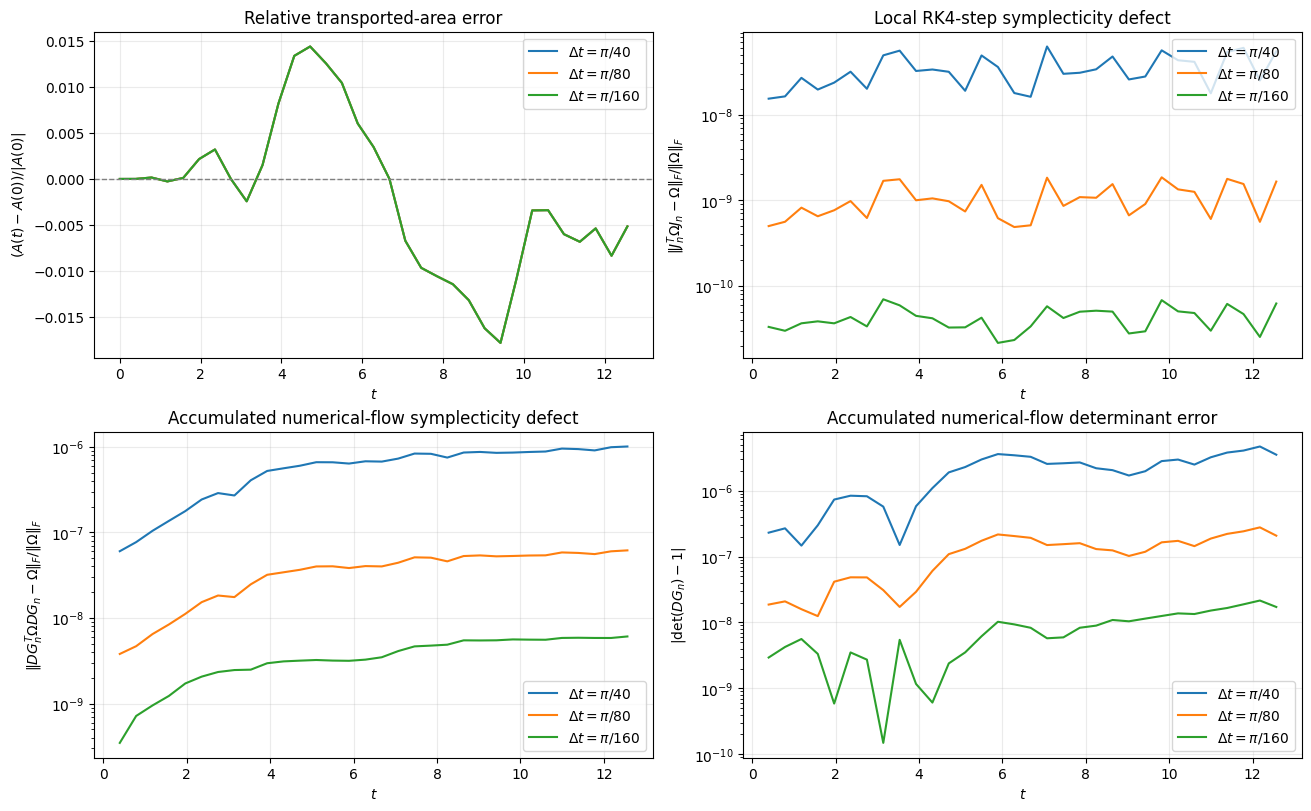

In [4]:
diagnostic_figure, diagnostic_axes = result.plot_diagnostics()
diagnostic_figure

## Step-size convergence

The log–log comparison separates the one-step defect from its accumulation over the fixed physical interval. The empirical orders printed above are computed from the maximum accumulated defect for adjacent step sizes.

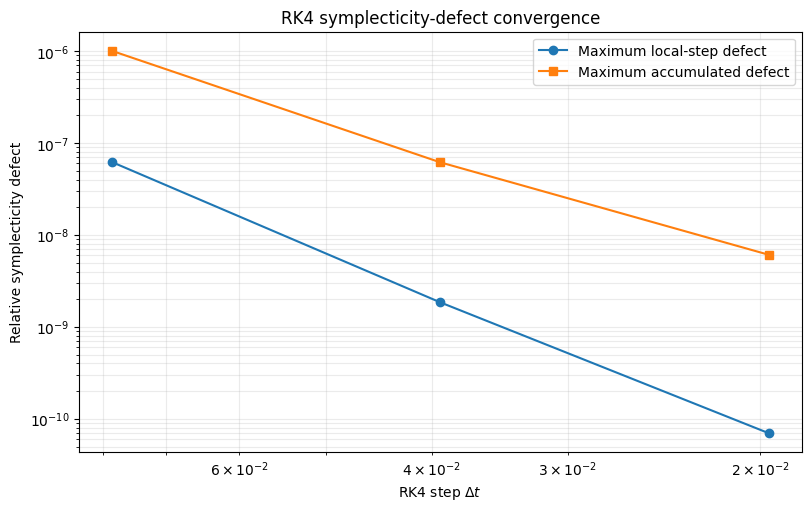

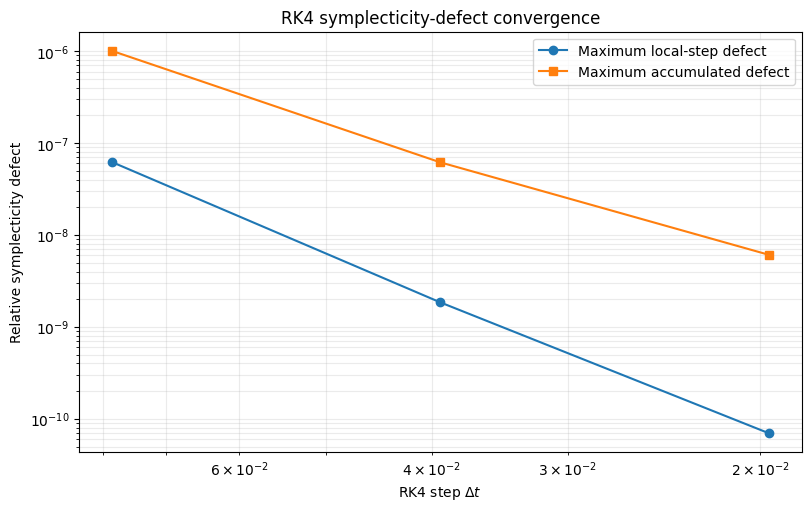

In [5]:
convergence_figure, convergence_axis = result.plot_convergence()
convergence_figure

## Comparative animation

The animation synchronizes the effective potential, transported RK4 contours, relative area error, and accumulated physical-flow symplecticity defect. The same color identifies each RK4 step size in every panel.

In [6]:
display_animation(
    result.animate(
        frames=None,
        interval=120,
    )
)

## Interpretation

Classical RK4 is fourth-order accurate but is not a symplectic integrator. The measured maximum accumulated defects decrease from approximately $1.01\times10^{-6}$ to $6.17\times10^{-8}$ and $6.09\times10^{-9}$. The first refinement gives empirical order $4.03$; the second gives $3.34$, indicating that the finest run is beginning to interact with accumulated finite-difference round-off. The determinant error decreases consistently with the symplecticity defect. In contrast, the maximum relative polygon-area error remains near $1.78\times10^{-2}$ for all three steps, showing that this quantity is dominated here by the common 16-vertex spatial discretization rather than the RK4 temporal step. A finer finite-difference sensitivity study or an analytic tangent equation would be appropriate before interpreting the finest-grid slope as an asymptotic RK4 order.